# 12 — Rendering Surface Results

Notebook 11 showed that a facade/roof request returns a
`SurfaceAnalysisResult` instead of a gridded `AreaResult`. This notebook is
the rendering companion: how to turn those per-surface UV sensor grids into
pictures on the geometry you submitted. Requires `infrared-sdk >= 0.4.12`.

Each entry in `result.surfaces` is keyed `"{building-id}/{surface-index}"`
(the building id is *your own* key from the geometry you submitted) and is a
`SurfaceSensorGrid`:

| Field | Meaning |
|---|---|
| `origin`, `u_axis`, `v_axis` | grid anchor + in-plane unit vectors (metres, your coordinate frame) |
| `grid_size`, `nu`, `nv` | cell edge length and grid dimensions |
| `values` | `nu * nv` sensor values, row-major in v (`index = j * nu + i`); `None` = masked cell outside the footprint |
| `cell_area`, `cell_tris` | per-cell real covered area and its exact clipped triangles (flat `[x,y,z, ...]`, 9 floats per triangle) |

We run one facade+roof sky-view-factor job, then show the **two integration
routes**: **Route 1 — texture-style** (reshape `values`, map `None`→`NaN`,
`imshow` with bilinear filtering) and **Route 2 — exact geometry** (build a 3D
mesh straight from `cell_tris`). We finish with the facade-vs-roof
normalization tip.

In [1]:
from dotenv import load_dotenv

load_dotenv()

import numpy as np
import matplotlib.pyplot as plt

from infrared_sdk import InfraredClient, SurfaceAnalysisResult
from infrared_sdk.analyses.types import AnalysesName, SvfModelRequest
from cities import get

city = get("munich")

client = InfraredClient()
area = client.buildings.get_area(city.polygon_small)
print(f"Found {area.total_buildings} buildings.")

No base_url provided and INFRARED_BASE_URL env var not set; falling back to DEFAULT_BASE_URL (https://api.infrared.city/v2)


[INFO] [SDK:BigPayload] route=inline url=https://api.infrared.city/v2/buildings raw_bytes=188 threshold=5242880 enabled=True


[INFO] [SDK:BigPayload] inline ok url=https://api.infrared.city/v2/buildings status=200 elapsed_ms=2428 response_bytes=868351 x-amzn-requestid=eb9ca6c6-d56e-4758-89d9-b27e6049a6a4


Found 329 buildings.


## 1. Run one facade + roof job

`analysis_surfaces="all"` synthesises sensor grids on **every** facade *and*
roof surface; `surface_grid_size=1.0` puts a sensor every metre. This is the
same `run_area_and_wait` call as a normal area analysis — passing
`analysis_surfaces` is what flips the result type to `SurfaceAnalysisResult`.
(A request this dense can exceed the server's per-job sensor cap; when it does
the SDK transparently splits it into sub-jobs and merges them back into one
result — **each sub-job is billed separately**.)

In [2]:
payload = SvfModelRequest(
    analysis_type=AnalysesName.sky_view_factors,
    analysis_surfaces="all",  # facades + roofs
    surface_grid_size=1.0,  # one sensor per metre
)

result = client.run_area_and_wait(payload, city.polygon_small, buildings=area.buildings)

assert isinstance(result, SurfaceAnalysisResult)
print(f"{len(result.surfaces)} surfaces, {result.sensor_count} sensors")
print(f"legend bounds: [{result.min_legend}, {result.max_legend}]")

[INFO] [SDK:Area] run_area start phase=initial analyses=sky-view-factors max_workers=20 max_tiles_override=None buildings=yes vegetation=no ground_materials=no


[INFO] [SDK:Area] run_area tiled non_empty_tiles=1 grid=1x1


[INFO] [SDK:Layers] resolve_layers non_empty_tiles=1 buildings_in=329 vegetation_in=0 ground_materials_in=0


[INFO] [SDK:Area] run_area_single phase=initial analysis=sky-view-factors non_empty_tiles=1 retry_filter_size=0 config_hash=96c205c80534


[INFO] [SDK:Area] run_area_single phase=initial analysis=sky-view-factors tile_payloads_built=2


...

[INFO] [SDK:Polling] check_area_state analysis=sky-view-factors counts={'Running': 1, 'Succeeded': 1} is_complete=False


[INFO] [SDK:Polling] check_area_state analysis=sky-view-factors counts={'Succeeded': 2} is_complete=True


[INFO] [SDK:Polling] check_area_state analysis=sky-view-factors counts={'Succeeded': 2} is_complete=True


[INFO] [SDK:Merge] merge_surface_area_jobs analysis=sky-view-factors jobs_total=2 mode=surface-union


1908 surfaces, 320776 sensors
legend bounds: [0.0, 100.0]


## 2. Per-building aggregates

`result.aggregates["buildings"]` gives a ready-made `area` / `mean` / `peak`
per building — no grid crunching needed. These are what you'd use to colour
whole elements in a dashboard or rank buildings.

In [3]:
buildings_agg = result.aggregates["buildings"]
top5 = sorted(buildings_agg.items(), key=lambda kv: kv[1].area, reverse=True)[:5]
print(f"{'building id':>36}   area(m2)   mean SVF   peak SVF")
for building_id, agg in top5:
    print(f"{building_id:>36}   {agg.area:8.0f}   {agg.mean:8.1f}   {agg.peak:8.1f}")

                         building id   area(m2)   mean SVF   peak SVF
33e9dbb4-5e90-4e18-9f83-428ad4fa2b08      45349       71.1      100.0
ed86d808-e079-47db-b726-17e263def095      34629       41.9       99.9
962fe190-feec-4a82-ab36-d0c8fb997c45      12173       56.4       99.9
f1603681-2496-40ed-9b84-953f4755651b       9876       77.1      100.0
68dc9fff-42b1-4fa4-9225-756a935e99ce       8426       66.5       98.9


## 3. Route 1 — texture-style rendering

The fast route. Reshape a surface's `values` into its `(nv, nu)` grid, map
masked cells (`None`) to `NaN`, and hand it to `imshow`. Bilinear
interpolation gives the smooth gradient for free — the exact same texture with
`nearest` filtering is the "raw cells" view. **Interpolation is a display
choice, not an API request**: the grid is the lossless truth; smoothing happens
at render time.

We classify surfaces facade-vs-roof by `v_axis` verticality (a facade's
in-plane `v_axis` points up the wall, so `|v_axis[2]|` ≈ 1) and pick the
largest facade for the clearest texture.

> Note the `NaN` cells bleed slightly under bilinear filtering at the
> footprint edge — in a real GPU pipeline you'd premultiply a mask channel
> (see the reference) to keep those edges crisp.

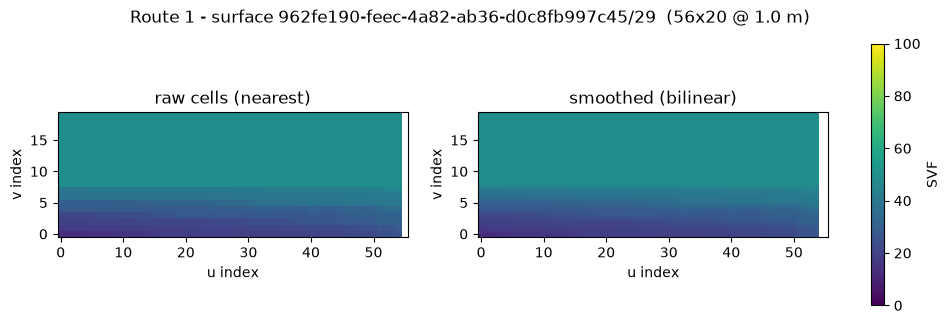

In [4]:
def surface_grid(surface):
    """values -> (nv, nu) float array, masked cells as NaN."""
    return np.array(
        [v if v is not None else np.nan for v in surface.values],
        dtype=float,
    ).reshape(surface.nv, surface.nu)


def is_facade(surface, tol=0.5):
    """Facade = vertical in-plane v_axis (points up the wall)."""
    return abs(surface.v_axis[2]) > tol


facades = {k: s for k, s in result.surfaces.items() if is_facade(s)}
key, surface = max(facades.items(), key=lambda kv: kv[1].area)
grid = surface_grid(surface)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, interp, title in (
    (axes[0], "nearest", "raw cells (nearest)"),
    (axes[1], "bilinear", "smoothed (bilinear)"),
):
    im = ax.imshow(
        grid,
        origin="lower",
        cmap="viridis",
        vmin=result.min_legend,
        vmax=result.max_legend,
        interpolation=interp,
    )
    ax.set_title(title)
    ax.set_xlabel("u index")
    ax.set_ylabel("v index")
fig.colorbar(im, ax=axes, label="SVF", fraction=0.046)
fig.suptitle(
    f"Route 1 - surface {key}  ({surface.nu}x{surface.nv} @ {surface.grid_size} m)"
)
plt.show()

## 4. Route 2 — exact-geometry rendering from `cell_tris`

The crisp route. `cell_tris[k]` is that cell already clipped to the surface's
true outline (flat `[x, y, z, ...]`, 9 floats per triangle — a cell can carry
more than one triangle). Emit those triangles directly, coloured by the cell's
`value`, and boundaries are exact — no stepping — because the server did the
clipping.

We render one building's surfaces as a matplotlib `Poly3DCollection`. To keep
the plot interactive we pick the richest building whose triangle count stays
under a budget.

building fd18a169...: 11 surfaces, 11870 triangles


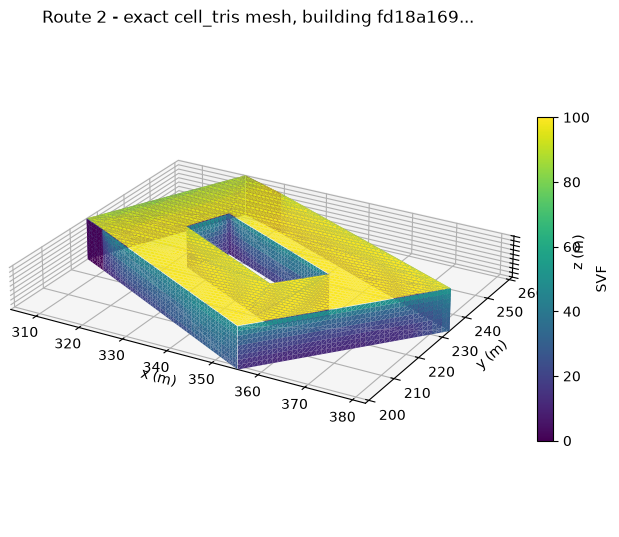

In [5]:
from collections import defaultdict
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Group surfaces by building id (key = "{building-id}/{surface-index}").
by_building = defaultdict(list)
for k, s in result.surfaces.items():
    by_building[k.rsplit("/", 1)[0]].append(s)


def triangle_count(surfaces):
    return sum(len(t) // 9 for s in surfaces for t in s.cell_tris if t)


CAP = 12000
counts = {b: triangle_count(surfs) for b, surfs in by_building.items()}
eligible = {b: c for b, c in counts.items() if 0 < c <= CAP}
bid = max(eligible, key=eligible.get)
surfaces = by_building[bid]
print(f"building {bid[:8]}...: {len(surfaces)} surfaces, {counts[bid]} triangles")

# Flatten every clipped cell triangle, tagged with its cell value.
polys, vals = [], []
for s in surfaces:
    for value, tris in zip(s.values, s.cell_tris):
        if not tris or value is None:
            continue
        for t in range(0, len(tris), 9):
            polys.append(
                [
                    (tris[t + 0], tris[t + 1], tris[t + 2]),
                    (tris[t + 3], tris[t + 4], tris[t + 5]),
                    (tris[t + 6], tris[t + 7], tris[t + 8]),
                ]
            )
            vals.append(value)

cmap = plt.get_cmap("viridis")
norm = Normalize(vmin=result.min_legend, vmax=result.max_legend)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.add_collection3d(
    Poly3DCollection(polys, facecolors=cmap(norm(vals)), edgecolors="none")
)

pts = np.array([p for tri in polys for p in tri])
lo, hi = pts.min(0), pts.max(0)
span = np.where(hi - lo > 0, hi - lo, 1.0)
ax.set_xlim(lo[0], hi[0])
ax.set_ylim(lo[1], hi[1])
ax.set_zlim(lo[2], hi[2])
ax.set_box_aspect(span)
ax.view_init(elev=25, azim=-60)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title(f"Route 2 - exact cell_tris mesh, building {bid[:8]}...")
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="SVF", shrink=0.6)
plt.show()

## 5. Facade vs roof: normalise them separately

Horizontal surfaces see far more open sky than walls, so roofs pile up at the
top of the scale and squeeze all the facade variation into a narrow band of a
shared colormap. Classify by `v_axis` verticality, then give facades their own
colour scale when facades are the story. Below, the same facade surface is
drawn on the shared legend and on a facade-only scale — the facade-only scale
recovers contrast the shared scale hides.

facades:  199050 sensors, SVF  -0.0- 49.7  mean 21.5
roofs:    121726 sensors, SVF  25.2-100.0  mean 96.8


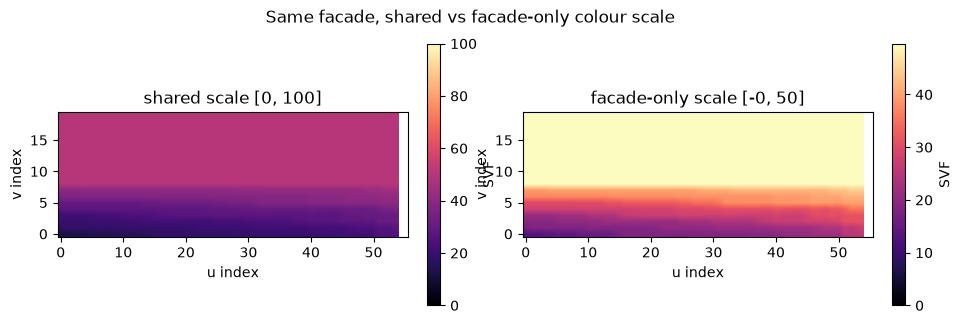

In [6]:
facade_vals, roof_vals = [], []
for s in result.surfaces.values():
    clean = [v for v in s.values if v is not None]
    (facade_vals if is_facade(s) else roof_vals).extend(clean)

facade_vals = np.array(facade_vals)
roof_vals = np.array(roof_vals)
print(
    f"facades: {facade_vals.size:>7} sensors, SVF {facade_vals.min():5.1f}-{facade_vals.max():5.1f}  mean {facade_vals.mean():4.1f}"
)
print(
    f"roofs:   {roof_vals.size:>7} sensors, SVF {roof_vals.min():5.1f}-{roof_vals.max():5.1f}  mean {roof_vals.mean():4.1f}"
)

f_lo, f_hi = np.percentile(facade_vals, [2, 98])
grid = surface_grid(surface)  # the facade surface from Route 1

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
im0 = axes[0].imshow(
    grid,
    origin="lower",
    cmap="magma",
    vmin=result.min_legend,
    vmax=result.max_legend,
    interpolation="bilinear",
)
axes[0].set_title(f"shared scale [{result.min_legend:.0f}, {result.max_legend:.0f}]")
fig.colorbar(im0, ax=axes[0], fraction=0.046, label="SVF")
im1 = axes[1].imshow(
    grid, origin="lower", cmap="magma", vmin=f_lo, vmax=f_hi, interpolation="bilinear"
)
axes[1].set_title(f"facade-only scale [{f_lo:.0f}, {f_hi:.0f}]")
fig.colorbar(im1, ax=axes[1], fraction=0.046, label="SVF")
for ax in axes:
    ax.set_xlabel("u index")
    ax.set_ylabel("v index")
fig.suptitle("Same facade, shared vs facade-only colour scale")
plt.show()

## Notes

- **Building ids round-trip.** Surface keys reuse the `building-id` you
  submitted, so results map straight back onto your elements.
- **Never zero-fill masked cells.** `None` means the cell centre is outside
  the surface footprint — cut or skip it; don't treat it as `0`.
- **Both routes, one job.** Route 1 (texture) is ideal for a fast city-scale
  overview; Route 2 (`cell_tris`) for crisp exportable geometry on selected
  elements. They read the same `SurfaceAnalysisResult`.

See the `surface-results-integration` reference for the GPU-shader texture
atlas + premultiplied-mask recipe.